# BAB 2 - Seaborn Statistical Plots
Seaborn adalah *library* visualisasi data tingkat tinggi yang dibangun di atas Matplotlib. Di dunia *Machine Learnin*, *Seaborn* sangat disukai karena kodenya jauh lebih ringkas, tampilan visualnya lebih modern secara *default*, dan terintegrasi secara langsung dengan **Pandas DataFrame**.

## A. Integrasi dengan Pandas DataFrame
Berbeda dengan Matplotlib yang menerima array/list terpisah, *Seaborn* dirancang untuk langsung membaca data dari objek DataFrame. Cukup memasukkan DataFrame ke parameter `data`, lalu memanggil nama kolomnya sebagai *string* pada parameter `x` atau `y`

```python
sns.scatterplot(data=data_rumah, x='Luas_Rumah', y='Harga', hue='Tipe_Cluster', ax=ax)
```

---

## B. Distribusi Data
Sebelum masuk ke pembuatan model ML, visualisasi distribusi fitur sangat penting untuk mendeteksi *outliners*, kecondongan data, atau melihat apakah data berdistribusi normal
* `sns.histplot()` : Menampilkan frakuensi kemunculan nilai data
* `sns.kddeplot()` : **Kernel Density Estimate**, menampilkan kurva tren halus dari kepadatan data
* `sns.boxplot()` : Melihat sebaran harga berdasarkan cluster dan mendeteksi outliners

    ```python
    sns.histplot(data=data_rumah, x="Harga", kde=True, color="Purple", ax=ax1)
    sns.boxplot(data=data_rumah, x="Tipe_Cluster", y="Harga", palette="Set2", ax=ax2)
    sns.kdeplot(data=data_rumah, x='Harga', fill=True, color='crimson', ax=ax3)
    ```

---

## C. Matriks Korelasi
Dilakukan untuk melakukan proses *Feature Selection* (memilih fitur terbaik untuk dimasukkan ke model)
* `sns.heatmap()` : Mengubah matriks korelasi angka (dari fungsi `.corr()` milik Pandas) menjadi visual warna

    ```python
    sns.heatmap(matriks_korelasi, annot=True, vmin=-1, vmax=1, ax=ax) 
    ```

---

## D. Visualisasi Cepat Semua Fitur Kontinu
* `sns.pairplot()` : Otomatis membuat grid visualisasi hubungan silang dari setiap kombinasi kolom numerik yang ada di DataFrame sekaligus

    ```python
    sns.pairplot(data=data_rumah, hue='Tipe_Cluster', palette='bright')
    ```

---

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Membuat DataFrame
np.random.seed(42)
data_rumah = pd.DataFrame({
    'Luas_Rumah': np.random.randint(50, 200, 100),
    'Harga': np.random.randint(300, 1500, 100),
    'Tipe_Cluster': np.random.choice(['Ekonomis', 'Premium', 'VIP'], 100)
})

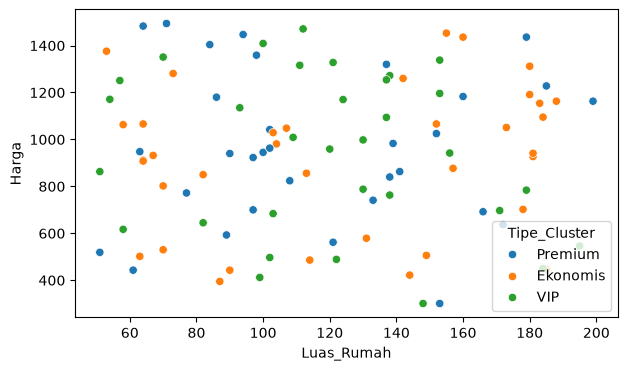

In [3]:
# Konsep Utama (Integrasi ke Pandas DataFrame)

# Membaut kanvas
fig, ax = plt.subplots(figsize=(7, 4))

# Hubungkan Seaborn ke objek 'ax' Matplotlib
sns.scatterplot(data=data_rumah, x='Luas_Rumah', y='Harga', hue='Tipe_Cluster', ax=ax)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_11472\3434617082.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_rumah, x="Tipe_Cluster", y="Harga", palette="Set2", ax=ax2)


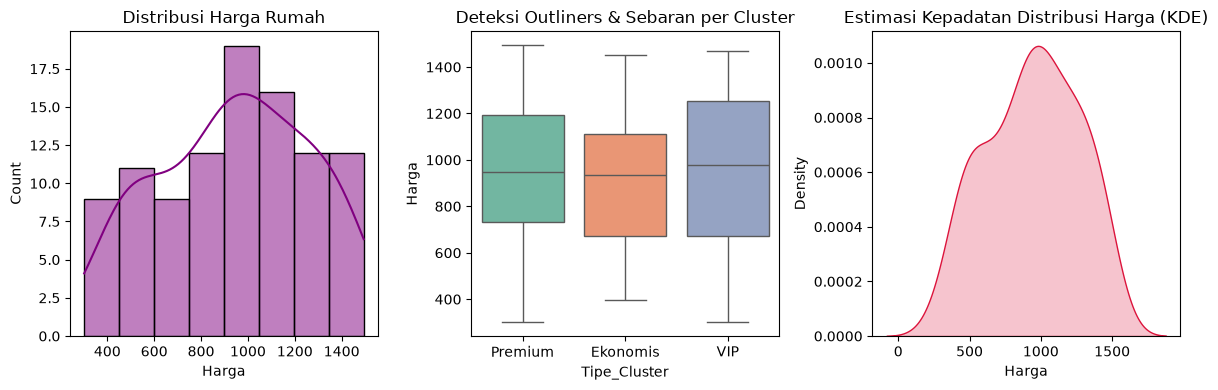

In [4]:
# Distribusi Data

# Membuat kanvas
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))

# 1. Histogram -> Melihat frekuensi kemunculan data
sns.histplot(data=data_rumah, x="Harga", kde=True, color="Purple", ax=ax1)
ax1.set_title("Distribusi Harga Rumah")

# 2. Boxplot -> Melihat sebaran harga berdasarkan cluster dan mendeteksi outliners
sns.boxplot(data=data_rumah, x="Tipe_Cluster", y="Harga", palette="Set2", ax=ax2)
ax2.set_title("Deteksi Outliners & Sebaran per Cluster")

# 3. Kdeplot -> Membuat tren dari distribusi data
sns.kdeplot(data=data_rumah, x='Harga', fill=True, color='crimson', ax=ax3)
ax3.set_title('Estimasi Kepadatan Distribusi Harga (KDE)')

plt.tight_layout()
plt.show()

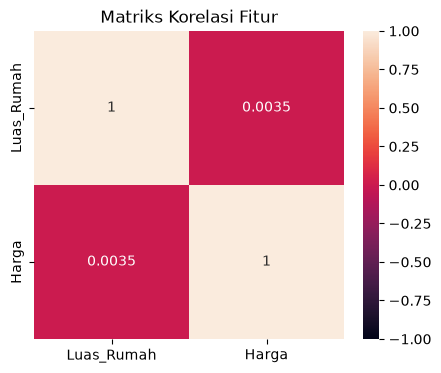

In [ ]:
# Matrix Korelasi

# Mengambil kolom numerik
matriks_korelasi = data_rumah[['Luas_Rumah', 'Harga']].corr()

# Membuat kanvas
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi dengan heatmap
sns.heatmap(matriks_korelasi, annot=True, vmin=-1, vmax=1, ax=ax) 
ax.set_title('Matriks Korelasi Fitur')

plt.show()

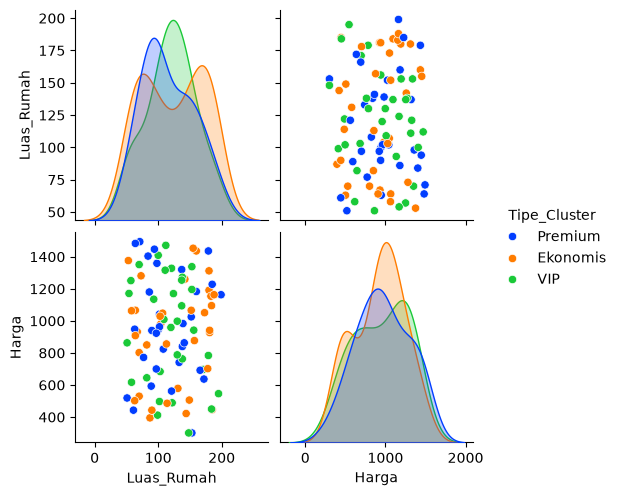

In [ ]:
# Visualisasi Cepat Semua Fitur
# digunakan untuk mempertemukan setiap fitur numerik dengan fitur numerik lainnya

sns.pairplot(data=data_rumah, hue='Tipe_Cluster', palette='bright')
plt.show()